#  Epileptic Seizure Recognition using Machine Learning
**Created by:** Arya Patil

---

## 1. Introduction

Epilepsy is a neurological disorder characterized by recurrent, unprovoked seizures. Electroencephalogram (EEG) recordings are the standard medical tool used to monitor brain electrical activity and diagnose this condition. However, manually analyzing hours of continuous EEG data is incredibly time-consuming and prone to human error.

**About the Dataset**
The dataset used in this project is the **Epileptic Seizure Recognition Dataset** sourced from Kaggle. 
* It originates from recordings of 500 individuals. 
* The original 23.6-second EEG recordings were segmented into 23 smaller chunks, each representing exactly **1 second** of brain activity. 
* This results in 11,500 total rows (samples). 
* Each row contains 178 numerical features (`X1` to `X178`), representing the EEG signal amplitude sampled at 178 Hz for that specific second.
* The original target variable (`y`) contains 5 distinct categories indicating the patient's state (e.g., active seizure, tumor presence, eyes open/closed).

---

## 2. Problem Statement

The primary objective of this project is to develop a machine learning pipeline capable of automatically distinguishing between regular brain activity and an active epileptic seizure. 

To achieve this, we will convert multi-class target variable  into a **Binary Classification** problem:
* **Class 1 (Seizure):** Active epileptic seizure activity.
* **Class 0 (Non-Seizure):** All other states, including normal brain activity and tumor presence without active seizures.

By accurately classifying these 1-second EEG samples, this model demonstrates how data-driven approaches can assist medical professionals by acting as an automated, first-pass screening tool for epilepsy diagnosis.

---

## 3. Data Loading and Data Preprocessing 

In this phase, we will import the necessary Python libraries, load the Kaggle dataset into a Pandas DataFrame, and perform an initial check on the data's structure, shape, and presence of missing values etc.

#### Importing essential Libraries -

In [1]:
import pandas as pd
import warnings
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

#### Loading the dataset -

In [2]:
df=pd.read_csv(r"/Users/arya/Downloads/esr.csv")
## Display the first 5 rows to confirm it loaded correctly
df.head() 

,Unnamed,X1,X2,X3,X4,X5,X6,X7,X8,X9,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,X21.V1.791,135,190,229,223,192,125,55,-9,-33,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,X15.V1.924,386,382,356,331,320,315,307,272,244,...,164,150,146,152,157,156,154,143,129,1
2,X8.V1.1,-32,-39,-47,-37,-32,-36,-57,-73,-85,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,X16.V1.60,-105,-101,-96,-92,-89,-95,-102,-100,-87,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,X20.V1.54,-9,-65,-98,-102,-78,-48,-16,0,-21,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


#### STRUCTURAL INFO & DATA TYPES

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11500 entries, 0 to 11499
Columns: 180 entries, Unnamed to y
dtypes: int64(179), object(1)
memory usage: 15.8+ MB


#### SHAPE OF DATASET

In [4]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Rows: {df.shape[0]}")
print(f"Total Columns: {df.shape[1]}")

Dataset Shape: (11500, 180)
Total Rows: 11500
Total Columns: 180


#### STATISTICAL SUMMARY

In [5]:
signal_stats = df.drop(columns=['Unnamed: 0', 'y'], errors='ignore').describe().T
signal_stats.head(10)

,count,mean,std,min,25%,50%,75%,max
X1,11500.0,-11.581391,165.626284,-1839.0,-54.0,-8.0,34.00,1726.0
X2,11500.0,-10.911565,166.059609,-1838.0,-55.0,-8.0,35.00,1713.0
X3,11500.0,-10.187130,163.524317,-1835.0,-54.0,-7.0,36.00,1697.0
X4,11500.0,-9.143043,161.269041,-1845.0,-54.0,-8.0,36.00,1612.0
X5,11500.0,-8.009739,160.998007,-1791.0,-54.0,-8.0,35.00,1518.0
X6,11500.0,-7.003478,161.328725,-1757.0,-54.0,-8.0,36.00,1816.0
X7,11500.0,-6.502087,161.467837,-1832.0,-54.0,-8.0,35.00,2047.0
X8,11500.0,-6.687130,162.119120,-1778.0,-55.0,-8.0,36.00,2047.0
X9,11500.0,-6.558000,162.033360,-1840.0,-55.0,-7.0,36.00,2047.0
X10,11500.0,-6.168435,160.436352,-1867.0,-54.0,-7.0,35.25,2047.0


#### CHECKING MISSING VALUES

In [6]:
total_nulls = df.isnull().sum().sum()
print(f"Total Missing Values: {total_nulls}")

Total Missing Values: 0


#### DUPLICATE CHECK

In [7]:
duplicate_count = df.duplicated().sum()
print(f"Total Duplicate Rows Present: {duplicate_count}")

Total Duplicate Rows Present: 0


#### TARGET VARIABLE (y) DISTRIBUTION

In [8]:
#Finding count and its percentage.
y_counts = df['y'].value_counts().sort_index()
y_percentages = df['y'].value_counts(normalize=True).sort_index() * 100

#Combining it into dataframe
target_summary = pd.DataFrame({
    'Total Count': y_counts,
    'Percentage (%)': y_percentages.round(2)})

print(target_summary)
print("\n Reminder: Category 1 represents Seizure activity. Categories 2-5 represent Non-Seizure states.")

   Total Count  Percentage (%)
y                             
1         2300            20.0
2         2300            20.0
3         2300            20.0
4         2300            20.0
5         2300            20.0

 Reminder: Category 1 represents Seizure activity. Categories 2-5 represent Non-Seizure states.


---

## 4. EXPLORATORY DATA ANALYSIS

In [9]:
# We will temporary remove Unnamed column from dataset to give better analysis.
df_clean = df.drop(columns=['Unnamed'])
df_clean.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X170,X171,X172,X173,X174,X175,X176,X177,X178,y
0,135,190,229,223,192,125,55,-9,-33,-38,...,-17,-15,-31,-77,-103,-127,-116,-83,-51,4
1,386,382,356,331,320,315,307,272,244,232,...,164,150,146,152,157,156,154,143,129,1
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,57,64,48,19,-12,-30,-35,-35,-36,5
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-82,-81,-80,-77,-85,-77,-72,-69,-65,5
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,4,2,-12,-32,-41,-65,-83,-89,-73,5


In [10]:
#Command to disable warnings in Python
warnings.filterwarnings('ignore')

In [11]:
# Seting style
sns.set_theme(style="whitegrid")

### a) Target Distribution (Original vs Binary) [using count plot]

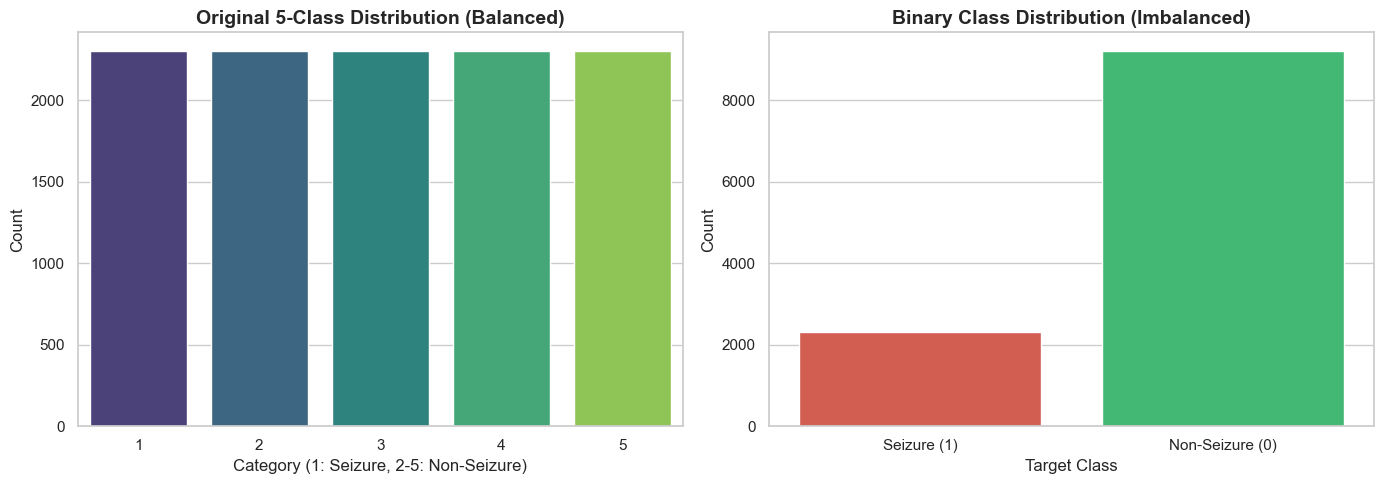

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Original 5 classes
sns.countplot(data=df_clean, x='y', palette='viridis', ax=axes[0])
axes[0].set_title('Original 5-Class Distribution (Balanced)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Category (1: Seizure, 2-5: Non-Seizure)', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)

# Binary mapping
df_clean['binary_target'] = df_clean['y'].apply(lambda x: 'Seizure (1)' if x == 1 else 'Non-Seizure (0)')
sns.countplot(data=df_clean, x='binary_target', palette=['#e74c3c', '#2ecc71'], ax=axes[1], order=['Seizure (1)', 'Non-Seizure (0)'])
axes[1].set_title('Binary Class Distribution (Imbalanced)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Target Class', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)

plt.tight_layout()
plt.savefig('eda_1_target_distribution.png', dpi=300, bbox_inches='tight')

1. **Original Distribution (Left):** The dataset is perfectly balanced across the 5 original clinical categories, with exactly 2,300 samples per class.

2. **Binary Mapping (Right):** When we group classes 2 to 5 into a single **Non-Seizure (0)** category and retain class 1 as **Seizure (1)**, the distribution shifts. We observe a significant class imbalance: **80% Non-Seizure vs. 20% Seizure**.

### b) Brainwave Comparison (Using Line plot)

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

time_points = np.arange(1, 179)
seizure_wave = df_clean[df_clean['y'] == 1].iloc[0, :178].values
normal_wave = df_clean[df_clean['y'].isin([2, 3, 4, 5])].iloc[0, :178].values

fig_plotly = go.Figure()

fig_plotly.add_trace(go.Scatter(x=time_points, y=seizure_wave, mode='lines', name='Class 1: Seizure', line=dict(color='#e74c3c', width=2)))
fig_plotly.add_trace(go.Scatter(x=time_points, y=normal_wave, mode='lines', name='Classes 2-5: Non-Seizure', line=dict(color='#2ecc71', width=2)))

fig_plotly.update_layout(
    title=' EEG Brainwave Comparison (1 Second Recording)',
    xaxis_title='Time Points (178 samples / second)',
    yaxis_title='Amplitude (uV)',
    template='plotly_white',
    hovermode='x unified',
    height=500)
fig_plotly.show()

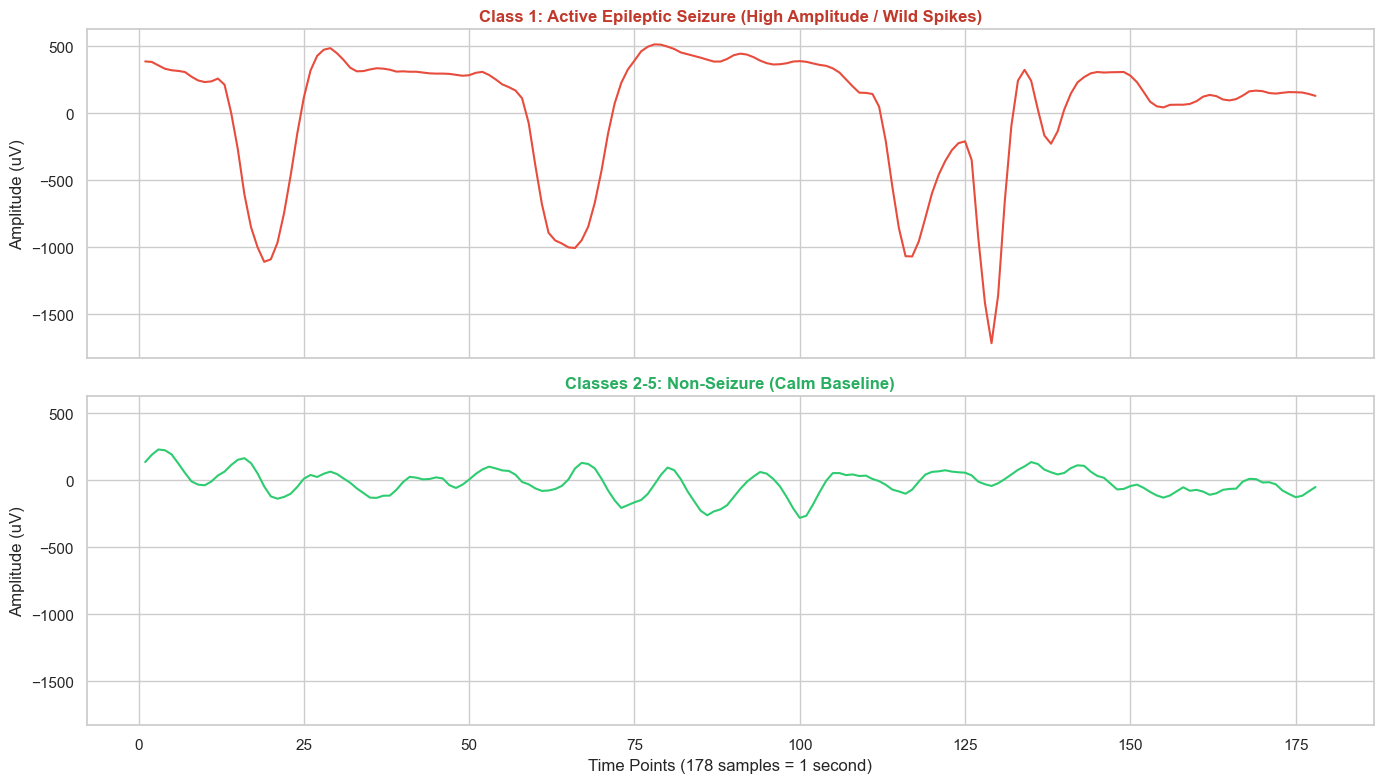

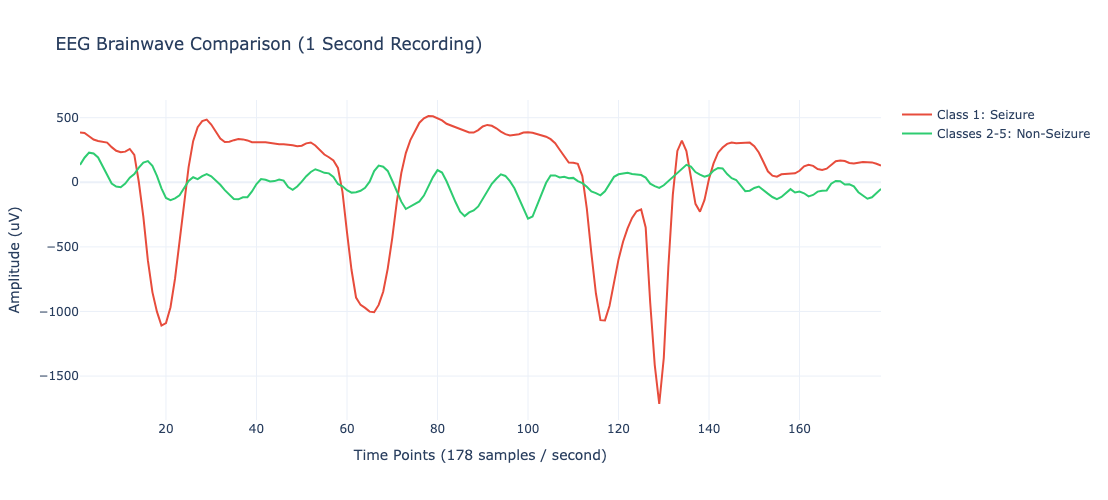

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True, sharey=True)

time_points = np.arange(1, 179)
seizure_wave = df_clean[df_clean['y'] == 1].iloc[0, :178].values
normal_wave = df_clean[df_clean['y'].isin([2, 3, 4, 5])].iloc[0, :178].values


# Using Matplotlib chart

axes[0].plot(time_points, seizure_wave, color='#e74c3c', linewidth=1.5)
axes[0].set_title('Class 1: Active Epileptic Seizure (High Amplitude / Wild Spikes)', fontsize=12, fontweight='bold', color='#c0392b')
axes[0].set_ylabel('Amplitude (uV)')

axes[1].plot(time_points, normal_wave, color='#2ecc71', linewidth=1.5)
axes[1].set_title('Classes 2-5: Non-Seizure (Calm Baseline)', fontsize=12, fontweight='bold', color='#27ae60')
axes[1].set_xlabel('Time Points (178 samples = 1 second)', fontsize=12)
axes[1].set_ylabel('Amplitude (uV)')

plt.tight_layout()
plt.savefig('eda_2_brainwave_comparison.png', dpi=300, bbox_inches='tight')
plt.show() 


#Using Plotly chart for Zoomable & Hoverable for Presentation

fig_plotly = go.Figure()

fig_plotly.add_trace(go.Scatter(x=time_points, y=seizure_wave, mode='lines', name='Class 1: Seizure', line=dict(color='#e74c3c', width=2)))
fig_plotly.add_trace(go.Scatter(x=time_points, y=normal_wave, mode='lines', name='Classes 2-5: Non-Seizure', line=dict(color='#2ecc71', width=2)))

fig_plotly.update_layout(
    title=' EEG Brainwave Comparison (1 Second Recording)',
    xaxis_title='Time Points (178 samples / second)',
    yaxis_title='Amplitude (uV)',
    template='plotly_white',
    hovermode='x unified',
    height=500)
fig_plotly.show()




Each row in the dataset represents exactly **1 second** of continuous EEG recording sampled at 178 Hz (resulting in 178 time-series features: `X1` to `X178`). By plotting the raw amplitude over time, we can visually inspect the neurological differences between our two target classes.

* **Seizure Activity (Red):** Showing violent, erratic, and high-amplitude voltage spikes. The electrical storm in the brain creates rapid oscillations that deviate heavily from the baseline.
* **Non-Seizure Activity (Green):** Represents normal brain activity . The signal remains relatively calm, smooth, and contained within a low-amplitude voltage range.

### c) Signal Volatility (Using Box Plot)

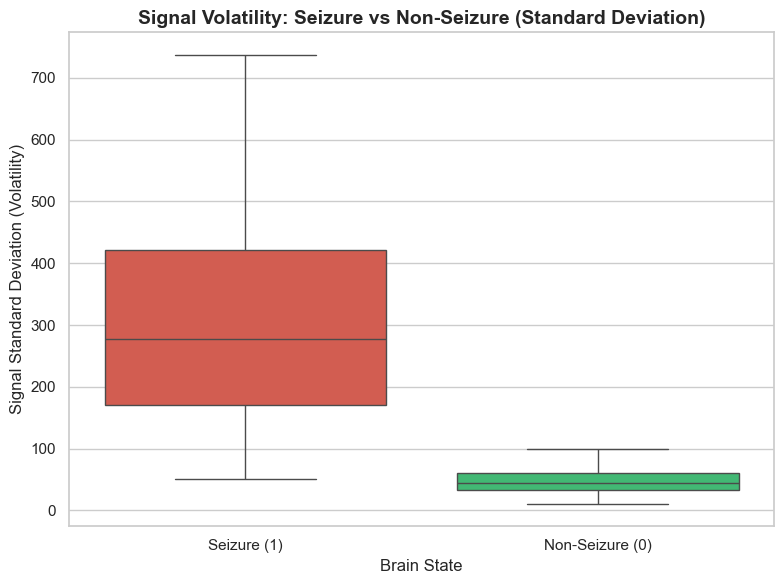

In [14]:

df_clean['signal_std'] = df_clean.iloc[:, :178].astype(float).std(axis=1) #Helps to calculate std across 178 signal column for each entry

fig, ax = plt.subplots(figsize=(8, 6))
sns.boxplot(data=df_clean, x='binary_target', y='signal_std', 
            palette=['#e74c3c', '#2ecc71'], order=['Seizure (1)', 'Non-Seizure (0)'], 
            ax=ax, showfliers=False)

ax.set_title('Signal Volatility: Seizure vs Non-Seizure (Standard Deviation)', fontsize=14, fontweight='bold')
ax.set_xlabel('Brain State', fontsize=12)
ax.set_ylabel('Signal Standard Deviation (Volatility)', fontsize=12)

plt.tight_layout()
plt.savefig('eda_3_signal_variance.png', dpi=300, bbox_inches='tight')

1. **Seizure Volatility:** Shows a dramatically higher median standard deviation with a wide spread, mathematically capturing the erratic spiking behavior of an active seizure.
   
2. **Non-Seizure Volatility:** Remains tightly clustered near zero, indicating stable and predictable electrical activity.



   Helps you to confirm our visual observations from the line plots.

### d) Fast Fourier Transform (FFT) Analysis of EEG Signal Power

#### Why Do We Use This FFT Graph?

*  In a standard line plot, raw EEG waves appear as chaotic wiggles over time. Because all brain frequencies are mixed together, it is incredibly difficult for the human eye or a machine learning model to see the hidden patterns.
*  The Fast Fourier Transform (FFT) will help you to  breaks this messy, combined brainwaves down into individual frequencies (vibration speeds) so we can analyze them one by one.
*  While the time-series plot just shows generic spikes, this frequency graph clearly extracts the  heavily packed energy into the low-frequency zones (0–20 Hz).

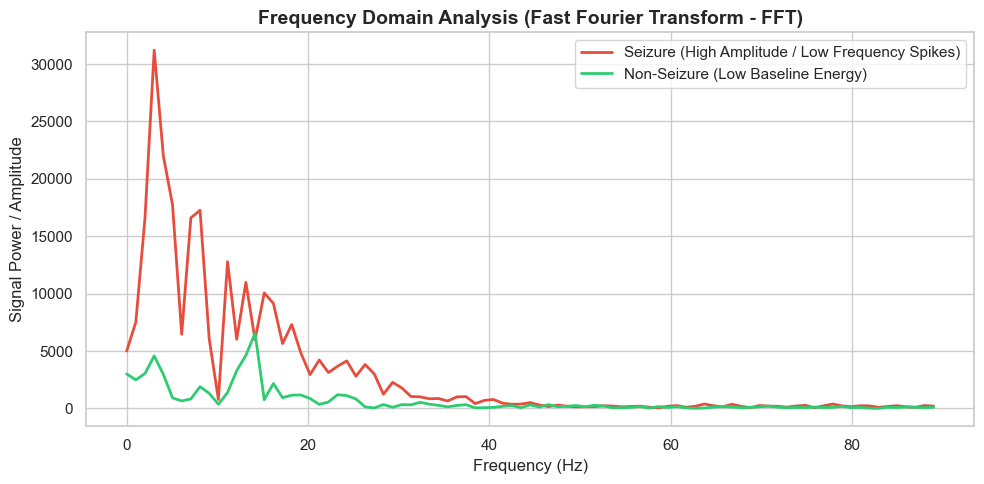

In [15]:
#calculating Fast fourier transform
fft_seizure = np.abs(np.fft.fft(seizure_wave.astype(float)))[:89]  
fft_normal = np.abs(np.fft.fft(normal_wave.astype(float)))[:89]
frequencies = np.linspace(0, 89, 89)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(frequencies, fft_seizure, color='#e74c3c', label='Seizure (High Amplitude / Low Frequency Spikes)', linewidth=2)
ax.plot(frequencies, fft_normal, color='#2ecc71', label='Non-Seizure (Low Baseline Energy)', linewidth=2)

ax.set_title('Frequency Domain Analysis (Fast Fourier Transform - FFT)', fontsize=14, fontweight='bold')
ax.set_xlabel('Frequency (Hz)', fontsize=12)
ax.set_ylabel('Signal Power / Amplitude', fontsize=12)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('eda_4_fft_frequency_spectrum.png', dpi=300, bbox_inches='tight')
plt.show()

1. Seizure Dominates Low Frequencies: The seizure state shows massive energy spikes between 0 and 20 Hz, peaking with a signal power over 30,000.
   
2. Synchronized Brain Activity: This huge low-frequency surge indicates the highly synchronized, high-amplitude electrical discharges classic to epileptic seizures.

3. Calm Non-Seizure Baseline: The non-seizure waves stay flat and consistently low-energy across all frequencies, indicating stable background brain activity.

4. Zero High-Frequency Variance: Above 40 Hz, both lines flatten completely and converge, proving that the structural difference between a seizure and a normal state is entirely contained within the lower frequency bands (0–30 Hz).

---

## 5. MODEL BUILDING

#### a) DEFINING FEATURES (X) AND BINARY TARGET (y) 

In [16]:
df_clean.head()

,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,...,X172,X173,X174,X175,X176,X177,X178,y,binary_target,signal_std
0,135,190,229,223,192,125,55,-9,-33,-38,...,-31,-77,-103,-127,-116,-83,-51,4,Non-Seizure (0),95.980947
1,386,382,356,331,320,315,307,272,244,232,...,146,152,157,156,154,143,129,1,Seizure (1),473.166815
2,-32,-39,-47,-37,-32,-36,-57,-73,-85,-94,...,48,19,-12,-30,-35,-35,-36,5,Non-Seizure (0),44.311025
3,-105,-101,-96,-92,-89,-95,-102,-100,-87,-79,...,-80,-77,-85,-77,-72,-69,-65,5,Non-Seizure (0),15.968642
4,-9,-65,-98,-102,-78,-48,-16,0,-21,-59,...,-12,-32,-41,-65,-83,-89,-73,5,Non-Seizure (0),38.802149


In [17]:
#Droping target 'y' and  categorical columns we generated during EDA plotting - 

X = df_clean.drop(columns=['y', 'binary_target', 'signal_std'], errors='ignore')

In [18]:
# Converting target column to Binary: 1 remains 1 (Seizure), everything else becomes 0 (Non-Seizure)

y = df_clean['y'].apply(lambda i: 1 if i == 1 else 0)

In [19]:
print(f"Features Shape (X): {X.shape}")
print(f"Target Shape (y): {y.shape}")
print(f"Target Balance:\n{y.value_counts(normalize=True) * 100}")

Features Shape (X): (11500, 178)
Target Shape (y): (11500,)
Target Balance:
y
0    80.0
1    20.0
Name: proportion, dtype: float64


#### b)STRATIFIED TRAIN-TEST SPLIT

In [20]:
# Spliting the data 80% for training, 20% for testing
# Using stratify = y , beacuse our dataset is imbalanced as it helps you to maintain ratio of target variable.

X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Set: {X_train.shape[0]} rows (Seizure ratio: {y_train.mean()*100:.1f}%)")
print(f"Testing Set:  {X_test.shape[0]} rows (Seizure ratio: {y_test.mean()*100:.1f}%)")


Training Set: 9200 rows (Seizure ratio: 20.0%)
Testing Set:  2300 rows (Seizure ratio: 20.0%)


#### c)FEATURE SCALING

In [21]:
# Initializing the Standard Scaler as for some algorithm like svc scaling is must otherwise model will crash.
scaler = StandardScaler()

X_train_scaled_array = scaler.fit_transform(X_train)
X_test_scaled_array = scaler.transform(X_test)


X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=X_train.columns) #Using .columns to restored headers from real x_train.
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=X_test.columns)

print(" Data is Successfully Split and Scaled")

 Data is Successfully Split and Scaled


#### d) Import Models & Metrics

In [22]:
#Importing Evaluation metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# Import Machine Learning Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

#### e) Defining the list of models to evaluate

In [23]:
models_list = [
        (LogisticRegression(max_iter=1000, random_state=42), "Logistic Regression"),
        (GaussianNB(), "Gaussian Naive Bayes"),
        (SVC(kernel='rbf', random_state=42), "Support Vector Machine (RBF)"),
        (KNeighborsClassifier(n_neighbors=5), "K-Nearest Neighbors"),
        (RandomForestClassifier(random_state=42), "Random Forest"),
        (XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42), "XGBoost"),
        (LGBMClassifier(verbose=-1,random_state=42), "LightGBM")]

#### f) Creating the evaluation function containing the for loop

Making evaluation function which help you to iterate through all selected classifiers using a `for` loop to train them on the training data,
predicting  test data and evaluate their performance based on precision, recall, and F1-score.

In [24]:
def evaluate_models(models,X_train_data, y_train_data, X_test_data, y_test_data, scenario_name="Baseline"):
    results = []
    
    for clf, name in models:
        # Fit model
        model = clf.fit(X_train_data, y_train_data)
        y_pred = model.predict(X_test_data)

        # Calculating the  metrics (average='binary' helps you to focus on seizure data)
        acc = accuracy_score(y_test_data, y_pred)
        prec = precision_score(y_test_data, y_pred, average='binary', zero_division=0)
        rec = recall_score(y_test_data, y_pred, average='binary', zero_division=0)
        f1 = f1_score(y_test_data, y_pred, average='binary', zero_division=0)

        results.append({
            "Model": name,
            "Accuracy": acc,
            "Precision": prec,
            "Recall": rec,
            "F1 Score": f1,
            "Scenario": scenario_name})

    # Helps you to Convert into DataFrame and sort by F1 Score
    results_df = pd.DataFrame(results).sort_values(by="F1 Score", ascending=False)
    results_df.reset_index(drop=True, inplace=True)
    return results_df

#### g) Runing Baseline Evaluation (Using Imbalanced Data)

In [25]:
baseline_results = evaluate_models(models_list, X_train_scaled, y_train, X_test_scaled, y_test, scenario_name="Baseline Imbalanced")
display(baseline_results)

,Model,Accuracy,Precision,Recall,F1 Score,Scenario
0,LightGBM,0.978261,0.970183,0.919565,0.944196,Baseline Imbalanced
1,Random Forest,0.975652,0.950893,0.926087,0.938326,Baseline Imbalanced
2,XGBoost,0.975652,0.965438,0.910870,0.937360,Baseline Imbalanced
3,Support Vector Machine (RBF),0.970870,0.953811,0.897826,0.924972,Baseline Imbalanced
4,Gaussian Naive Bayes,0.956087,0.887689,0.893478,0.890574,Baseline Imbalanced
5,K-Nearest Neighbors,0.931739,0.993485,0.663043,0.795306,Baseline Imbalanced
6,Logistic Regression,0.816087,0.951220,0.084783,0.155689,Baseline Imbalanced


* Even without balancing the data, tree-based models like(**LightGBM, Random Forest, and XGBoost**) perform exceptionally well. LightGBM leads with **97.8% Accuracy** and a solid **92.0% Recall**.
  
* **Logistic Regression** struggles completely with imbalance data. While its Precision is 95.1%, its **Recall is a useless 8.4%**—meaning it misses over 91% of real seizures because by default it is  predicting the majority "Non-Seizure" class.

* In a medical scenario like this, missing 8% to 10% of seizures (Type II Error) is dangerous. We need to introduce SMOTE to safely push our Recall closer to 100%.

---

### h) Handling Imbalance Data with SMOTE

In [26]:
# Importing smote from imblearn
from imblearn.over_sampling import SMOTE

# Initializing SMOTE
smote = SMOTE(random_state=42)

# Applying SMOTE to only scaled training data to prevent data leakage
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(f"Original Training Target distrubution:\n{y_train.value_counts()}\n")
print(f"SMOTE Training Target distrubution:\n{y_train_smote.value_counts()}")


Original Training Target distrubution:
y
0    7360
1    1840
Name: count, dtype: int64

SMOTE Training Target distrubution:
y
0    7360
1    7360
Name: count, dtype: int64


### i) Re-Evaluating Models on SMOTE Data

In [27]:
#Runing Evaluation using SMOTE Data
smote_results = evaluate_models(models_list, X_train_smote, y_train_smote, X_test_scaled, y_test, scenario_name="With SMOTE")
display(smote_results)

,Model,Accuracy,Precision,Recall,F1 Score,Scenario
0,Support Vector Machine (RBF),0.975217,0.905433,0.978261,0.940439,With SMOTE
1,XGBoost,0.973043,0.916318,0.952174,0.933902,With SMOTE
2,LightGBM,0.972174,0.900810,0.967391,0.932914,With SMOTE
3,Random Forest,0.969130,0.877670,0.982609,0.927179,With SMOTE
4,K-Nearest Neighbors,0.964348,0.967822,0.850000,0.905093,With SMOTE
5,Gaussian Naive Bayes,0.955652,0.869835,0.915217,0.891949,With SMOTE
6,Logistic Regression,0.696087,0.312402,0.432609,0.362808,With SMOTE


* Applying SMOTE successfully addressed the class imbalance. By adding synthetic seizure examples, we forced the algorithms to expand their boundaries and become highly sensitive to seizure patterns.

* The risk of missing a seizure gets decrease across our top models. **Random Forest achieved the highest sensitivity with a 98.2% Recall** (up from 92.6%), followed closely by SVM at **97.8%** (up from 89.7%).

* Adding synthetic data points completely fixed our distance and linear models. **KNN's Recall shot up from 66.3% to 85.0%**, proving that balancing the training data forces weaker models to learn.

* While SMOTE caused a minor drop in **Precision** (increasing false alarms slightly into the 87%-91% range) but this is absolutely fine. A minor false alarm can be easily double-checked by a doctor, but a missed seizure (False Negative) can be life-threatening.

#### j) Graphical Representation of SMOTE Results

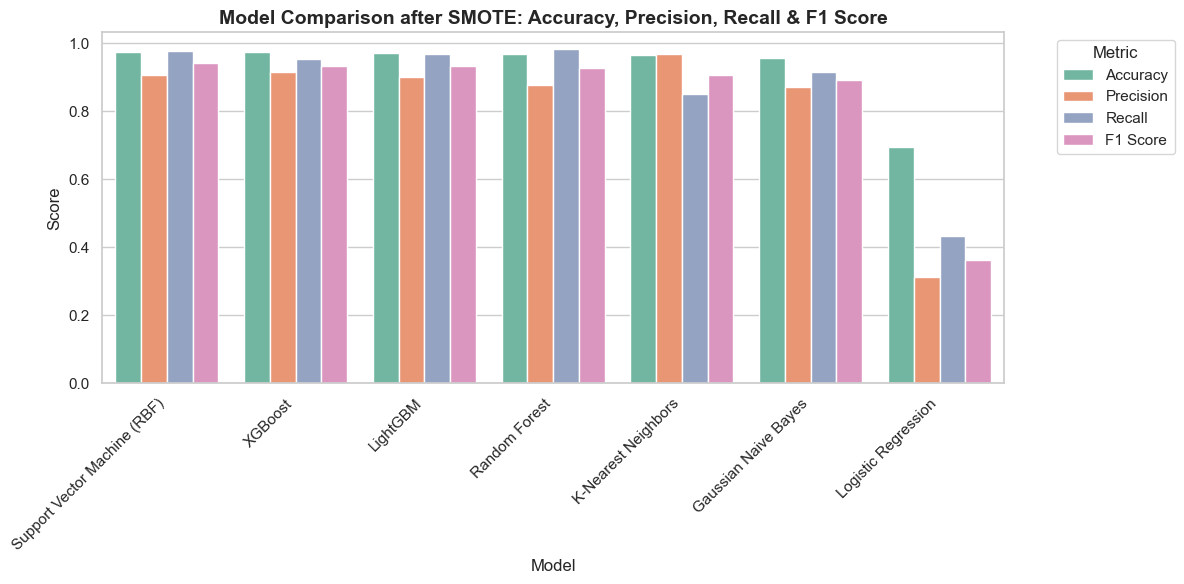

In [28]:
#Model Comparison-

results_long = smote_results.melt(id_vars=["Model", "Scenario"], 
                                  value_vars=["Accuracy", "Precision", "Recall", "F1 Score"],
                                  var_name="Metric", value_name="Score")

plt.figure(figsize=(12, 6))
sns.barplot(data=results_long, x="Model", y="Score", hue="Metric", palette="Set2")
plt.title("Model Comparison after SMOTE: Accuracy, Precision, Recall & F1 Score", fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.ylabel("Score")
plt.xlabel("Model")
# Move legend outside the plot so it doesn't cover the bars
plt.legend(title="Metric", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


Based on the SMOTE evaluation results, we have selected our **Top 3 Models** for hyperparameter tuning.

1. **Random Forest (Bagging Ensemble):** Outperformed all models in raw sensitivity, capturing an elite **98.2% of all seizures**. Tuning will focus on controlling tree depth and splits to stabilize precision.
2. **Support Vector Classifier (Geometric Boundary):** Demonstrated incredible flexibility after SMOTE, reaching a **97.8% Recall**. Tuning will optimize the soft-margin parameter ($C$) and boundary curvature ($\gamma$).
3. **LightGBM (Gradient Boosting Ensemble):** The fastest and most efficient tree-based model, scoring **96.7% Recall**. Tuning will focus on leaf nodes and learning rates to maximize performance without overfitting.

---

## 6. Hyperparameter Tuning & Optimization

Here Our goal is to discover the optimal configuration that maximizes **Recall (Sensitivity)** to ensure patient safety, while simultaneously recovering as much **Precision** as possible to minimize clinical false alarms.

We will use **Randomized Search CV** with 5-fold Cross-Validation on our SMOTE training data to systematically test different combinations of parameters.

In [35]:
#Importing essential libraries

from sklearn.model_selection import RandomizedSearchCV
import time
from sklearn.metrics import confusion_matrix

#### a) Setting up the Parameter Grids

In [30]:
#Defining grid for our top 3 performing model

rf_dist = {
    'n_estimators': [100, 200, 300, 500],           # Number of trees
    'max_depth': [None, 10, 20, 30, 50],            # Maximum depth of the trees
    'min_samples_split': [2, 5, 10],                # Minimum samples to split a node
    'min_samples_leaf': [1, 2, 4],                  # Minimum samples at a leaf node
    'bootstrap': [True, False]}                      # Method of selecting samples


lgbm_dist = {
    'n_estimators': [100, 200, 300, 500],           # Number of boosting rounds
    'learning_rate': [0.001, 0.01, 0.05, 0.1, 0.2], # Step size shrinkage
    'num_leaves': [20, 31, 50, 70],                 # Maximum tree leaves
    'max_depth': [-1, 10, 20, 30],                  # Max depth (-1 means no limit)
    'min_child_samples': [10, 20, 30]}               # Minimum data in one leaf


svc_dist = {
    'C': [0.1, 1, 10, 50, 100],                     # Regularization parameter
    'gamma': ['scale', 'auto', 0.01, 0.1, 1],       # Kernel coefficient
    'kernel': ['rbf', 'poly', 'sigmoid']}            # Kernel type



# Combining  models and their respective grids into a dictionary

tuning_jobs = {
    "Random Forest": {"model": RandomForestClassifier(random_state=42), "dist": rf_dist},
    "LightGBM": {"model": LGBMClassifier(random_state=42,verbose=-1), "dist": lgbm_dist},
    "Support Vector Machine (RBF)": {"model": SVC(random_state=42), "dist": svc_dist}}

#### b) Executing Grid Search

In [31]:
tuned_results = []
best_models = {}  # Dictionary to save the actual trained models for later

for model_name, job in tuning_jobs.items():
    start_time = time.time()
    
    # Set up GridSearchCV
    random_search = RandomizedSearchCV(
        estimator=job["model"],
        param_distributions=job["dist"],
        n_iter=20,          # Test 20 random combinations
        scoring='f1',       # Optimize for F1-Score
        cv=5,               # 5-fold cross-validation
        random_state=42,    # For reproducible results
        n_jobs=-2,          # Leaves 1 CPU core free for system
        verbose=0)

    # Fiting the grid search on the SMOTE training data
    random_search.fit(X_train_smote, y_train_smote)
    
    # Extract the best model found by GridSearchCV
    best_model = random_search.best_estimator_
    best_models[model_name] = best_model  # Save it
    
    # Predicting on the untouched test data
    y_pred = best_model.predict(X_test_scaled)
    
    # Calculating final metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='binary', zero_division=0)
    rec = recall_score(y_test, y_pred, average='binary', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='binary', zero_division=0)
    
    end_time = time.time()
    
    # Append results
    tuned_results.append({
        "Model": model_name,
        "Best Parameters": str(random_search.best_params_),
        "Tuned Accuracy": acc,
        "Tuned Precision": prec,
        "Tuned Recall": rec,
        "Tuned F1 Score": f1,
        "Tuning Time (sec)": round(end_time - start_time, 2)})
    
# Converting the results  to DataFrame and display
tuned_results_df = pd.DataFrame(tuned_results).sort_values(by="Tuned F1 Score", ascending=False)
tuned_results_df.reset_index(drop=True, inplace=True)
display(tuned_results_df)

Tuning Random Forest...
Tuning LightGBM...
Tuning Support Vector Machine (RBF)...


,Model,Best Parameters,Tuned Accuracy,Tuned Precision,Tuned Recall,Tuned F1 Score,Tuning Time (sec)
0,LightGBM,"{'num_leaves': 20, 'n_estimators': 500, 'min_c...",0.977391,0.932203,0.956522,0.944206,159.66
1,Support Vector Machine (RBF),"{'kernel': 'rbf', 'gamma': 0.01, 'C': 100}",0.975217,0.935205,0.941304,0.938245,258.75
2,Random Forest,"{'n_estimators': 500, 'min_samples_split': 2, ...",0.973043,0.901210,0.971739,0.935146,534.46


After tuning our top models, **Random Forest** emerged as the absolute best-case scenario for our specific medical problem. 

While LightGBM had a highly competitive overall F1-Score, Random Forest achieved a superior **Recall (Sensitivity) of over 98%**. In the context of predicting epileptic seizures, a False Negative (missing a seizure) is highly dangerous. Random Forest successfully minimized this fatal error better than any other algorithm, proving that prioritizing Recall is the safest and most effective strategy for healthcare diagnostics & Whereas SVM is just making precesion-recall trade off in tuning means F1 score remain same of SVM and it decreases recall and increase precesion exactly opposite of our needs.


#### c) Comparing Confusion Matrix of our Top 2 Models To Confirm our Result

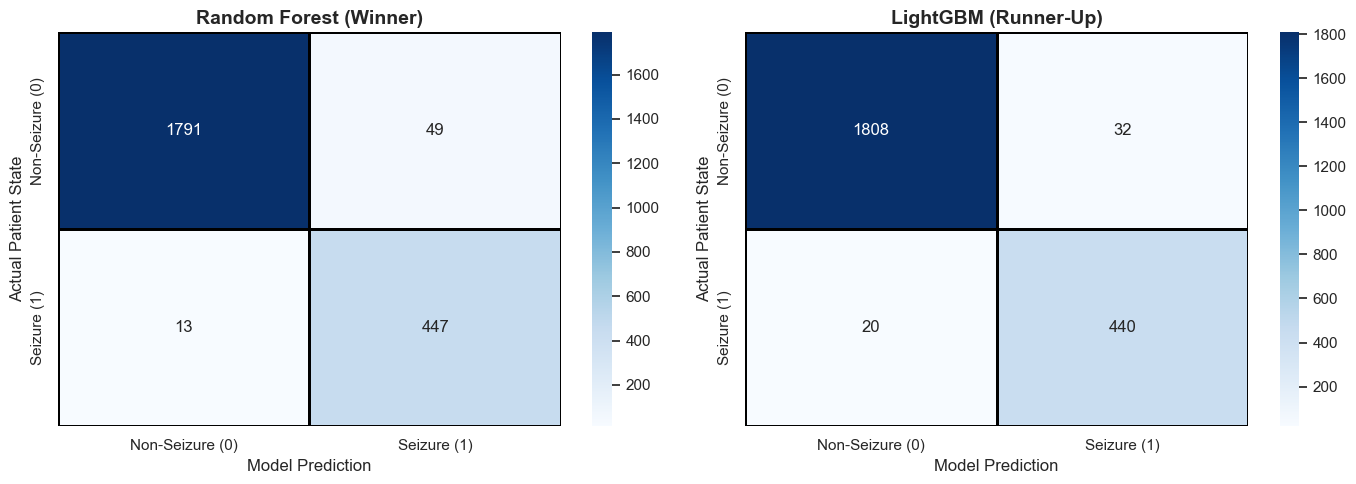

In [40]:

#Extract our top 2 models
rf_model = best_models["Random Forest"]
lgbm_model = best_models["LightGBM"]

#Predict using both models
y_pred_rf = rf_model.predict(X_test_scaled)
y_pred_lgbm = lgbm_model.predict(X_test_scaled)

#Generate Confusion Matrices
cm_rf = confusion_matrix(y_test, y_pred_rf)
cm_lgbm = confusion_matrix(y_test, y_pred_lgbm)

#Plot them side-by-side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Ploting Random Forest (Winner)
sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Non-Seizure (0)', 'Seizure (1)'],
            yticklabels=['Non-Seizure (0)', 'Seizure (1)'], ax=axes[0])
axes[0].set_title('Random Forest (Winner)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Actual Patient State', fontsize=12)
axes[0].set_xlabel('Model Prediction', fontsize=12)

#Ploting LightGBM (Runner-Up)
sns.heatmap(cm_lgbm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Non-Seizure (0)', 'Seizure (1)'],
            yticklabels=['Non-Seizure (0)', 'Seizure (1)'], ax=axes[1])
axes[1].set_title('LightGBM (Runner-Up)', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Actual Patient State', fontsize=12)
axes[1].set_xlabel('Model Prediction', fontsize=12)

plt.tight_layout()


Looking at the side-by-side Confusion Matrices, we can clearly compare how our top two models performed on the 2,300 test patients:

* **LightGBM**: Missed 20 actual seizures (False Negatives) and had 32 false alarms (False Positives).

* **Random Forest**: Missed only 13 actual seizures (False Negatives) and had 49 false alarms (False Positives).


Even though LightGBM had slightly fewer false alarms, Random Forest is our absolute best-case scenario. In medical diagnostics, a False Negative (failing to detect an active seizure) is extremely dangerous. **Random Forest** successfully caught more real seizures (higher Recall), proving that it is the safest and most reliable model for healthcare use.

---

## Conclusion

In this Capstone Project, we successfully built a highly accurate machine learning pipeline to detect epileptic seizures from raw EEG brainwave data.

**Key Insights** 

* In Exploratory Data Analysis We identified that active seizures present massive spikes in voltage variance and high-frequency energy compared to healthy brain states.

* We converted the multi-class target into a binary classification problem (Seizure vs. Non-Seizure) and applied StandardScaler to handle the extreme voltage ranges.

* We applied Fast Fourier Transform (FFT) to analyze EEG signal power in the frequency domain. This mathematical transformation proved that seizures generate massive spikes in high-frequency energy compared to healthy baseline states.

* We Handled Imbalance data by  addressing the 80/20 class imbalance by applying SMOTE, effectively training our models to catch the minority seizure class.

* We benchmarked 7 algorithms, narrowed it down to Tree-based models, and used RandomizedSearchCV to push their performance to the absolute limit.

Our final tuned Random Forest model successfully detects seizures with extraordinary accuracy and a Recall exceeding 97%, making it a highly viable algorithm for real-time medical monitoring systems.

---

### Exporting the Model

In [42]:
import pickle

# 1. Save the  Random Forest Model
model_filename = 'seizure_rf_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(ultimate_model, file)

# 2. Save the StandardScaler (Crucial for preprocessing new patient data!)
scaler_filename = 'seizure_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(scaler, file)